# Direct GeoTIFF Gridded Rain-on-Grid


This notebook authors an explicit precipitation GeoTIFF time series on the `BaldEagleCrkMulti2D` RasExamples mesh, translates it to a durable project-local NetCDF, validates the temporary precompute HDF, computes the plan, and plots final cell precipitation and hydraulic depth. GeoTIFF is a ras-commander ingestion format; it is not advertised as a native HEC-RAS meteorology source. Global gridded meteorology requires HEC-RAS 6.0 or later.


In [1]:
# DEVELOPMENT MODE TOGGLE: True uses this checkout; False uses the installed package.
USE_LOCAL_SOURCE = True

import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if REPO_ROOT.name.lower() == "examples":
    REPO_ROOT = REPO_ROOT.parent
if USE_LOCAL_SOURCE and str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


In [2]:
from __future__ import annotations

from datetime import datetime
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import xarray as xr
from rasterio.transform import from_origin

from ras_commander import (
    RasCmdr, RasExamples, RasPlan, RasPreprocess, RasUnsteady, init_ras_project,
)
from ras_commander.hdf import HdfMesh, HdfResultsMesh, HdfResultsPlan
from ras_commander.results import ResultsParser

RUN_ROOT = Path(os.environ.get(
    "RAS_COMMANDER_EXAMPLE_RUN_ROOT",
    REPO_ROOT / "working" / "example_729_geotiff_rain_on_grid",
))
RAS_VERSION = os.environ.get("RAS_COMMANDER_EXAMPLE_RAS_VERSION", "6.6")
EVENT_START = datetime(2024, 8, 9, 10)
EVENT_END = datetime(2024, 8, 9, 16)
RAIN_TIMES = [datetime(2024, 8, 9, hour) for hour in (11, 12, 13)]
RUN_ROOT.mkdir(parents=True, exist_ok=True)


## Check the selected HEC-RAS release


In [3]:
capabilities = RasUnsteady.get_gridded_precipitation_capabilities(RAS_VERSION)
capabilities.require_global_gridded()
display(pd.DataFrame([{
    "version": capabilities.version,
    "native_sources": ", ".join(capabilities.native_sources),
    "ras_commander_inputs": ", ".join(capabilities.ras_commander_inputs),
    "geotiff_qualification": capabilities.qualification_for("geotiff"),
    "timing": capabilities.period_average_timing,
}]))


,version,native_sources,ras_commander_inputs,geotiff_qualification,timing
0,6.6,"dss, netcdf, grib","dss, netcdf, grib, geotiff",qualified_windows_and_wine,corrected


## Extract the RasExamples project and create deterministic GeoTIFF forcing


In [4]:
project_path = RasExamples.extract_project(
    "BaldEagleCrkMulti2D", output_path=RUN_ROOT, suffix="geotiff_729"
)
ras = init_ras_project(project_path, ras_version=RAS_VERSION, load_results_summary=False)

plan_row = None
for _, candidate in ras.plan_df.iterrows():
    candidate_u = str(candidate["unsteady_number"]).zfill(2)
    config = RasUnsteady.get_met_precipitation_config(candidate_u, ras_object=ras)
    if config.get("enabled") and config.get("mode") == "Gridded":
        plan_row = candidate
        break
if plan_row is None:
    raise RuntimeError("No enabled gridded-precipitation plan in Bald Eagle")

PLAN_NUMBER = str(plan_row["plan_number"]).zfill(2)
UNSTEADY_NUMBER = str(plan_row["unsteady_number"]).zfill(2)
GEOMETRY_NUMBER = str(plan_row["geometry_number"]).zfill(2)
GEOMETRY_HDF = ras.project_folder / f"{ras.project_name}.g{GEOMETRY_NUMBER}.hdf"
mesh_areas = HdfMesh.get_mesh_areas(GEOMETRY_HDF)
if mesh_areas.crs is None:
    raise ValueError("The geometry fixture must have a projected CRS")

west, south, east, north = (float(value) for value in mesh_areas.total_bounds)
cell_size = max(east - west, north - south) / 24.0
width = max(2, int(np.ceil((east - west) / cell_size)))
height = max(2, int(np.ceil((north - south) / cell_size)))
transform = from_origin(west, north, cell_size, cell_size)
row, column = np.mgrid[:height, :width]
rain_frames = [
    0.5 + 0.5 * (column >= width // 2),
    0.25 + 0.75 * (row >= height // 2),
    0.1 + 0.9 * ((row + column) % 3 == 0),
]

geotiff_folder = ras.project_folder / "Precipitation" / "geotiff"
geotiff_folder.mkdir(parents=True, exist_ok=True)
geotiff_paths = []
for index, values in enumerate(rain_frames, start=1):
    path = geotiff_folder / f"synthetic_precip_{index:02d}.tif"
    with rasterio.open(
        path, "w", driver="GTiff", width=width, height=height, count=1,
        dtype="float32", transform=transform, crs=mesh_areas.crs, nodata=-9999.0,
    ) as dataset:
        dataset.write(np.asarray(values, dtype=np.float32), 1)
        dataset.update_tags(1, units="mm")
    geotiff_paths.append(path)

print(f"Created {len(geotiff_paths)} GeoTIFF frames at {height} x {width} cells")


2026-09-26 00:10:31 - ras_commander.RasExamples - INFO - Successfully extracted project 'BaldEagleCrkMulti2D' to BaldEagleCrkMulti2D_geotiff_729


2026-09-26 00:10:32 - ras_commander.RasPrj - INFO - ras-commander v0.102.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://rascommander.info | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-09-26 00:10:32 - ras_commander.RasPrj - INFO - Project initialized: BaldEagleDamBrk


2026-09-26 00:10:32 - ras_commander.RasPrj - INFO - Using HEC-RAS version 6.6


2026-09-26 00:10:32 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://rascommander.info/ras/
Repo: https://github.com/gpt-cmdr/ras-commander
LLM agents: https://rascommander.info/ras/llms.txt
═══════════════════════════════════════════════════════════════════════

SUPPORT OPEN-SOURCE DEVELOPMENT:
  Using RAS Commander? Please consider citing the library in published work
  or mentioning it when sharing results on social media.
  Agents are encouraged to suggest a RAS Commander v0.102.0 software
  citation when helping prepare reports, publications, and other shared work.
  Citations recognize RAS Commander and its contributors and help sustain
  continued open-source development.
  Citation and sharing guidance: https://rascommander.info/ras/cite/

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow 

Created 3 GeoTIFF frames at 17 x 24 cells


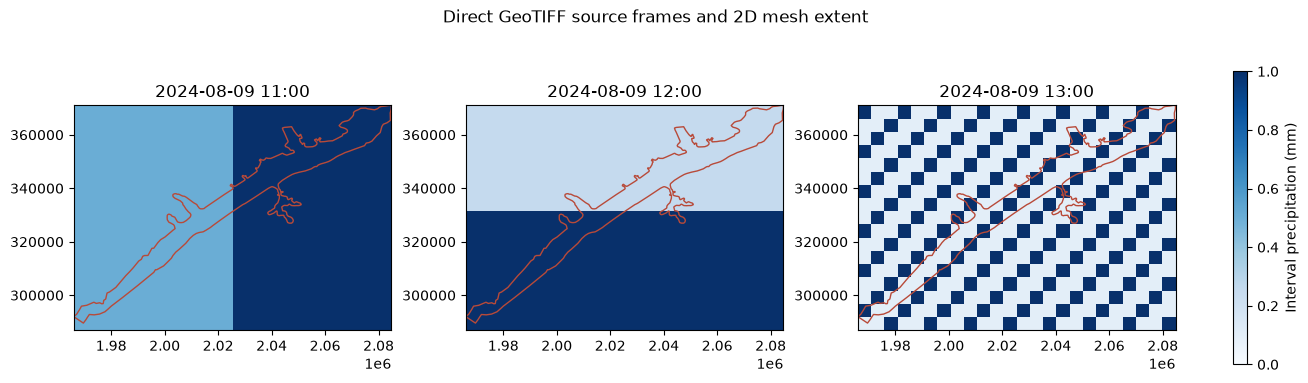

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
extent = [west, west + width * cell_size, north - height * cell_size, north]
for ax, values, timestamp in zip(axes, rain_frames, RAIN_TIMES):
    image = ax.imshow(values, extent=extent, origin="upper", cmap="Blues", vmin=0, vmax=1)
    mesh_areas.boundary.plot(ax=ax, color="#b84a39", linewidth=1.0)
    ax.set_title(timestamp.strftime("%Y-%m-%d %H:%M"))
    ax.set_aspect("equal")
fig.colorbar(image, ax=axes, shrink=0.8, label="Interval precipitation (mm)")
fig.suptitle("Direct GeoTIFF source frames and 2D mesh extent")
plt.show()


## Author the durable source and validate precompute rainfall


In [6]:
import_result = RasUnsteady.set_gridded_precipitation_geotiff(
    UNSTEADY_NUMBER,
    geotiff_paths,
    timestamps=RAIN_TIMES,
    units="mm",
    value_type="amount",
    first_timestep_hours=1.0,
    interpolation="Bilinear",
    ratio=1.0,
    nodata_policy="error",
    ras_object=ras,
)
assert import_result.cache_path.is_file()
assert import_result.shape == (4, height, width)
assert import_result.nodata_count == 0
print(
    "Durable NetCDF: "
    f"{import_result.cache_path.relative_to(ras.project_folder).as_posix()}"
)
print(f"Semantic content hash: {import_result.cache_hash}")

RasPlan.update_simulation_date(PLAN_NUMBER, EVENT_START, EVENT_END, ras_object=ras)
RasPlan.update_plan_intervals(
    PLAN_NUMBER, output_interval="1HOUR", instantaneous_interval="1HOUR",
    mapping_interval="1HOUR", ras_object=ras,
)
preprocess_result = RasPreprocess.preprocess_plan(PLAN_NUMBER, ras_object=ras, max_wait=600)
assert preprocess_result, preprocess_result.error
with h5py.File(preprocess_result.tmp_hdf_path, "r") as hdf:
    solver_values = hdf["Event Conditions/Meteorology/Precipitation/Values"][...]
    solver_timestamps = hdf["Event Conditions/Meteorology/Precipitation/Timestamp"][...]
assert solver_values.ndim == 2
assert solver_values.shape[0] == solver_timestamps.shape[0]
assert float(np.nanmax(solver_values)) > 0.0


2026-09-26 00:10:33 - ras_commander.RasUnsteady - INFO - Imported gridded precipitation into BaldEagleDamBrk.u03.hdf: 4 timesteps, 408 cells, range=0.0-3.0 mm


2026-09-26 00:10:33 - ras_commander.RasUnsteady - INFO - Configured gridded precipitation in BaldEagleDamBrk.u03: source=.\Precipitation\_ras_commander_cache\precip-513ec7c96a69e80d.nc, interpolation=Bilinear, dataset=precipitation


2026-09-26 00:10:33 - ras_commander.RasPlan - INFO - Updated simulation date in plan file: BaldEagleDamBrk.p06


2026-09-26 00:10:33 - ras_commander.RasPlan - INFO - Updated intervals in plan file: BaldEagleDamBrk.p06


2026-09-26 00:10:33 - ras_commander.RasPreprocess - INFO - Starting HEC-RAS preprocessing for plan 06


2026-09-26 00:10:33 - ras_commander.RasBco - INFO - Monitoring BaldEagleDamBrk.bco06 for 'Starting Unsteady Flow Computations' signal...


Durable NetCDF: Precipitation/_ras_commander_cache/precip-513ec7c96a69e80d.nc
Semantic content hash: 513ec7c96a69e80d1bd837d7f75b270374208fbd36403e2f9e03106e10f1e974


2026-09-26 00:10:46 - ras_commander.RasBco - INFO - Detected fresh preprocessing artifacts with materialized gridded precipitation


2026-09-26 00:10:46 - ras_commander.RasPreprocess - INFO - Preprocessing complete for plan 06 in 13.5s: tmp.hdf=12.0MB, b=3KB, x=5KB


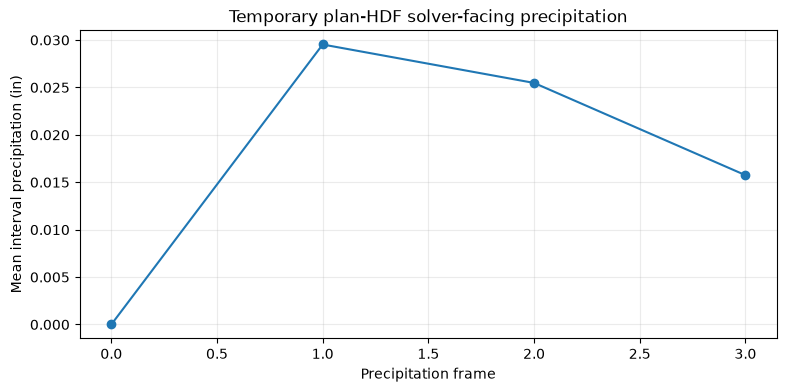

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(solver_values.shape[0]), np.nanmean(solver_values, axis=1), marker="o")
ax.set_title("Temporary plan-HDF solver-facing precipitation")
ax.set_xlabel("Precipitation frame")
ax.set_ylabel("Mean interval precipitation (in)")
ax.grid(True, alpha=0.25)
plt.show()


## Compute and inspect final HDF rainfall and hydraulic response


In [8]:
compute_result = RasCmdr.compute_plan(
    PLAN_NUMBER, ras_object=ras, force_rerun=True, verify=True,
    use_optimal_hdf_settings=True,
    hdf_output_variables=[
        "Cell Hydraulic Depth",
        "Cell Precipitation Rate",
        "Cell Cumulative Precipitation Depth",
    ],
)
assert compute_result
PLAN_HDF = ras.project_folder / f"{ras.project_name}.p{PLAN_NUMBER}.hdf"
messages = HdfResultsPlan.get_compute_messages_hdf_only(PLAN_HDF)
assert "Processing Precipitation data" in messages
parsed_messages = ResultsParser.parse_compute_messages(messages)
runtime = ResultsParser.parse_compute_messages_runtime(messages)
assert not parsed_messages["has_errors"], parsed_messages["first_error_line"]
display(pd.DataFrame([{
    "plan": f"p{PLAN_NUMBER}",
    "HEC-RAS version": RAS_VERSION,
    "completed": parsed_messages["completed"],
    "errors": parsed_messages["error_count"],
    "warnings": parsed_messages["warning_count"],
    "runtime (s)": runtime.get("runtime_complete_process_seconds"),
    "volume error (%)": runtime.get("vol_error_percent"),
}]))
precip_messages = [
    line for line in messages.splitlines()
    if any(term in line.casefold() for term in ("precip", "rain", "raster"))
]
print("\n".join(precip_messages) or "No precipitation-specific messages reported")


2026-09-26 00:10:46 - ras_commander.RasPlan - INFO - Updated HDF write parameters in plan file: BaldEagleDamBrk.p06


2026-09-26 00:10:46 - ras_commander.RasPlan - INFO - Added HDF output variable 'Cell Hydraulic Depth' to plan file: BaldEagleDamBrk.p06


2026-09-26 00:10:47 - ras_commander.RasPlan - INFO - Added HDF output variable 'Cell Precipitation Rate' to plan file: BaldEagleDamBrk.p06


2026-09-26 00:10:47 - ras_commander.RasPlan - INFO - Added HDF output variable 'Cell Cumulative Precipitation Depth' to plan file: BaldEagleDamBrk.p06


2026-09-26 00:10:47 - ras_commander.RasCmdr - INFO - Applied 'balanced' HDF settings profile to plan: BaldEagleDamBrk.p06


,plan,HEC-RAS version,completed,errors,warnings,runtime (s),volume error (%)
0,p06,6.6,True,0,0,19.0,0.000004


Plan: 'Gridded Precip - Infiltration' (BaldEagleDamBrk.p06)
Processing Precipitation data...
Finished Processing Precipitation data (0.141s)


,source-sampled cells compared,raining HDF cells,maximum source-vs-HDF error (in),final HDF minimum cumulative depth (in),final HDF mean cumulative depth (in),final HDF maximum cumulative depth (in),final HDF maximum ending rate (in/hr)
0,17591,18066,0.0,0.0,0.06159,0.115746,0.0


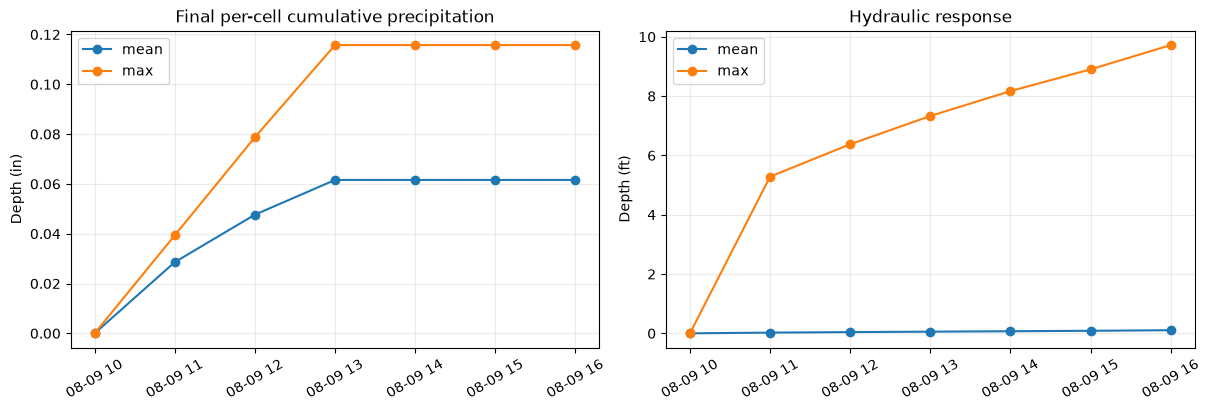

Manual review of the full HEC-RAS runtime messages and rainfall/results maps is still required.


In [9]:
cumulative = HdfResultsMesh.get_mesh_cells_timeseries(
    PLAN_HDF, var="Cell Cumulative Precipitation Depth"
)
rate = HdfResultsMesh.get_mesh_cells_timeseries(PLAN_HDF, var="Cell Precipitation Rate")
hydraulic = HdfResultsMesh.get_mesh_cells_timeseries(PLAN_HDF, var="Cell Hydraulic Depth")
mesh_name = next(iter(cumulative))
rain_data = cumulative[mesh_name]["Cell Cumulative Precipitation Depth"]
rate_data = rate[mesh_name]["Cell Precipitation Rate"]
depth_data = hydraulic[mesh_name]["Cell Hydraulic Depth"]
assert float(np.nanmax(rain_data.values)) > 0.0
assert float(np.nanmax(depth_data.values)) > 0.0
final_rain = np.asarray(rain_data.isel(time=-1).values, dtype=float)
final_rate = np.asarray(rate_data.isel(time=-1).values, dtype=float)
rain_steps = np.asarray(rain_data.values, dtype=float)
assert np.isfinite(final_rain).all() and np.isfinite(final_rate).all()
assert np.allclose(final_rate, 0.0, atol=1e-7)
assert float(np.nanmin(np.diff(rain_steps, axis=0))) >= -1e-7
mesh_cell_points = HdfMesh.get_mesh_cell_points(GEOMETRY_HDF)
with xr.open_dataset(import_result.cache_path) as cache_dataset:
    cache_final_mm = cache_dataset["precipitation"].isel(time=-1)
    expected_cell_in = (
        cache_final_mm.interp(
            x=xr.DataArray(mesh_cell_points.geometry.x.to_numpy(), dims="cell_id"),
            y=xr.DataArray(mesh_cell_points.geometry.y.to_numpy(), dims="cell_id"),
            method="linear",
        ).values
        / 25.4
    )
actual_cell_in = np.asarray(
    rain_data.isel(time=-1).sel(
        cell_id=mesh_cell_points["cell_id"].to_numpy(dtype=int)
    ).values,
    dtype=float,
)
comparison_mask = (actual_cell_in > 0.0) & np.isfinite(expected_cell_in)
comparison_error_in = actual_cell_in[comparison_mask] - expected_cell_in[comparison_mask]
assert int(comparison_mask.sum()) >= int(0.85 * len(mesh_cell_points))
assert float(np.max(np.abs(comparison_error_in))) <= 1e-5
display(pd.DataFrame([{
    "source-sampled cells compared": int(comparison_mask.sum()),
    "raining HDF cells": int(np.count_nonzero(actual_cell_in > 0.0)),
    "maximum source-vs-HDF error (in)": float(np.max(np.abs(comparison_error_in))),
    "final HDF minimum cumulative depth (in)": float(final_rain.min()),
    "final HDF mean cumulative depth (in)": float(final_rain.mean()),
    "final HDF maximum cumulative depth (in)": float(final_rain.max()),
    "final HDF maximum ending rate (in/hr)": float(final_rate.max()),
}]).round(6))

rain_time = pd.to_datetime(cumulative[mesh_name]["time"].values)
depth_time = pd.to_datetime(hydraulic[mesh_name]["time"].values)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(rain_time, rain_data.mean(dim="cell_id").values, marker="o", label="mean")
axes[0].plot(rain_time, rain_data.max(dim="cell_id").values, marker="o", label="max")
axes[0].set_title("Final per-cell cumulative precipitation")
axes[0].set_ylabel("Depth (in)")
axes[1].plot(depth_time, depth_data.mean(dim="cell_id").values, marker="o", label="mean")
axes[1].plot(depth_time, depth_data.max(dim="cell_id").values, marker="o", label="max")
axes[1].set_title("Hydraulic response")
axes[1].set_ylabel("Depth (ft)")
for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.legend()
    ax.tick_params(axis="x", rotation=30)
plt.show()
print("Manual review of the full HEC-RAS runtime messages and rainfall/results maps is still required.")
